# FR labour-supply data walkthrough — original data, step by step

Read the **original FR microdata**, then clean / filter / price it one inspectable step at a time. You see the dataframe and the household funnel after every step. No engine-ready files, no reproduction oracles.

**What is grounded vs. what you confirm**
- The **eligibility chain** (the cleaning/filtering logic) is transcribed from your DE adapter (`dclaborsupply_app.de.data_prep`), which is a deliberate FR-mirror — so these rules *are* the FR rules.
- The **column names** are the standardized EUROMOD input variables. Cell 1 checks which are actually present in your file, so you verify them — I'm not asserting your schema.
- The **one thing I cannot know** is the path to your FR raw file. It is the single `# CONFIRM (path)` below.
- Places where **FR genuinely differs from DE** are flagged `# FR-SPECIFIC`.

## 0. Read the original FR microdata

In [1]:
import numpy as np
import pandas as pd
from pathlib import Path
pd.set_option('display.max_columns', 80); pd.set_option('display.width', 200)

# THE ONE INPUT I CANNOT KNOW. Your FR EU-SILC / EUROMOD-input microdata file.
# EUROMOD input files are tab-separated .txt (same format as the DE_2017_a2.txt the
# DE adapter reads). Fill in the real path; I am deliberately not guessing it.
FR_RAW = Path('C:/Users/hisham/MNL/EUROMOD-STORAGE/Data/FR/FR_2016_a3.txt')   # CONFIRM (path)

raw = pd.read_csv(FR_RAW, sep='\t')   # EUROMOD input is tab-separated
print('raw shape   :', raw.shape)
print('n households:', raw['idhh'].nunique() if 'idhh' in raw else '? (no idhh col)')
print('n persons   :', len(raw))
raw.head()

raw shape   : (26560, 124)
n households: 11459
n persons   : 26560


,idhh,idperson,idfather,idmother,idpartner,idorighh,idorigperson,dag,dmb,dgn,dms,dcz,ddi,drgur,drgmd,drgru,ddt,dwt,dsu00,dsu01,dsu02,dncsy,dcu,dct,dec,decde,deh,dehde,dey,dew,drgn2,drgn1,drg01,les,lcs,lfs,lindi,liwmy,liwftmy,liwptmy,...,bchyc,bchcc,bchot,bsa00,bsaot,pdi00,bdi,bsuwd,bunmt,bunct,yempv,bsaoa,poa00,bhotn,bhoot,yem_hour,yem00,yemxp,amrrm,amrtn,ate,aco,aca,afc,xmp,xpp,xhc,xhcrt,xhcmomi,xhcot,e20ps_o,e20pspo_o,e20psmd_o,e20pslw_o,liwmy_f,lhw_f,liwwh_f,lunmy_f,yem_f,yse_f
0,1483000,148300001,0,0,148300002,1483000,148300001,55,5,1,2,2,0,1,0,0,22016,8113.981,0,147,48,0,1,5,0,-1,5,500,18,1984,1,1,1,2,1,5,6,12,0,12,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00000,0.0,0.0,0.0,0.0,0.0,0.0,72.190476,631.66667,0.00000,3,1,1,1,3,0.0,0.0,0.0,196.50,0.0,161.0,35.50,0,0,0,0,1,1,1,1,1,1
1,1483000,148300002,0,0,148300001,1483000,148300002,41,11,0,2,1,0,1,0,0,22016,8113.981,0,147,48,0,1,5,0,-1,5,500,18,2004,1,1,1,3,1,5,12,12,12,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00000,0.0,0.0,0.0,0.0,0.0,0.0,68.323810,2391.33330,597.83333,3,1,1,1,3,0.0,0.0,0.0,196.50,0.0,161.0,35.50,0,0,0,0,1,1,1,1,1,1
2,1483000,148300003,148300001,148300002,0,1483000,148300003,7,11,1,1,1,-1,1,0,0,22016,8113.981,0,147,48,0,0,5,2,10,0,0,0,-1,1,1,1,6,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00000,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.00000,0.00000,3,1,1,1,3,0.0,0.0,0.0,0.00,0.0,0.0,0.00,0,0,0,0,3,3,3,3,3,3
3,1483000,148300004,148300001,148300002,0,1483000,148300004,4,8,1,1,1,-1,1,0,0,22016,8113.981,0,147,48,0,0,5,1,0,0,0,0,-1,1,1,1,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00000,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.00000,0.00000,3,1,1,1,3,0.0,0.0,0.0,0.00,0.0,0.0,0.00,0,0,0,0,3,3,3,3,3,3
4,1484400,148440001,0,0,0,1484400,148440001,54,8,0,1,1,0,1,0,0,22016,9235.096,0,147,198,0,0,5,0,-1,3,353,13,1979,1,1,1,3,0,50,2,0,0,0,...,0.0,0.0,8.0,0.0,0.0,0.0,0.0,0.0,318.33333,0.0,0.0,0.0,0.0,0.0,0.0,72.363636,2321.66670,0.00000,6,4,1,1,1,0.0,0.0,0.0,749.33,435.0,0.0,314.33,10,0,1,0,1,1,1,1,1,1


## 1. Inspect the schema (you verify, not me)
Confirms which EUROMOD-standard variables your file actually carries, and which FR-specific ones are present.

In [2]:
print('--- all columns ---'); print(sorted(raw.columns)); print()

core = ['idhh','idperson','idpartner','dag','dgn','dms','dec','ddi','deh',
        'les','lhw','loc','yem','yse','yivwg']
print('core EUROMOD vars present:', [c for c in core if c in raw.columns])
print('core EUROMOD vars MISSING:', [c for c in core if c not in raw.columns])
print()
# FR-SPECIFIC variables to look for (these are where FR differs from the DE file):
fr_specific = ['lma','drgn1','drgur','drgmd','drgru','yem00','yemxp','dwt',
               'byr','pdi','poa','psu','idfather','idmother','idorighh']
for c in fr_specific:
    print(f'  {c:10s}: {"present" if c in raw.columns else "absent"}')

--- all columns ---
['aca', 'aco', 'afc', 'amrrm', 'amrtn', 'ate', 'bch00', 'bchcc', 'bched', 'bchlg', 'bchot', 'bchyc', 'bdi', 'bed', 'bfa', 'bhl', 'bho', 'bhoot', 'bhotn', 'bsa', 'bsa00', 'bsaoa', 'bsaot', 'bsuwd', 'bun', 'bunct', 'bunmt', 'bunmy', 'dag', 'dct', 'dcu', 'dcz', 'ddi', 'ddt', 'dec', 'decde', 'deh', 'dehde', 'dew', 'dey', 'dgn', 'dmb', 'dms', 'dncsy', 'drg01', 'drgmd', 'drgn1', 'drgn2', 'drgru', 'drgur', 'dsu00', 'dsu01', 'dsu02', 'dwt', 'e20ps_o', 'e20pslw_o', 'e20psmd_o', 'e20pspo_o', 'idfather', 'idhh', 'idmother', 'idorighh', 'idorigperson', 'idpartner', 'idperson', 'kfb', 'kfbcc', 'kfbmy', 'kivho', 'lcs', 'les', 'lfs', 'lhw', 'lhw_f', 'lindi', 'liwftmy', 'liwmy', 'liwmy_f', 'liwptmy', 'liwwh', 'liwwh_f', 'loc', 'lowas', 'lpemy', 'lse', 'lunmy', 'lunmy_f', 'pdi', 'pdi00', 'pdimy', 'poa', 'poa00', 'poamy', 'psu', 'psumy', 'tad', 'tis', 'tscer', 'twl', 'xhc', 'xhcmomi', 'xhcot', 'xhcrt', 'xmp', 'xpp', 'yds', 'ydses_o', 'yem', 'yem00', 'yem_f', 'yem_hour', 'yemmy', 'yem

## 2. Eligibility config (FR-mirror constants, from the DE adapter)
These are the frozen FR rule constants the DE adapter mirrors.

In [3]:
CONFIG = dict(
    age_range=(20, 60),
    allowed_les=(3, 5, 7),               # employee / unemployed / inactive deciders
    wage_bounds=(2.0, 170.0),            # employee-decider yivwg bounds
    other_member_income_threshold=50.0,  # |yem|/|yse| above this = earning non-decider
    hours_cap_high=70, hours_floor_low=10, hours_inactive_threshold=5,
    retire_cols=('byr', 'pdi', 'poa', 'psu'),   # CONFIRM FR benefit-receipt columns
)
CONFIG

{'age_range': (20, 60),
 'allowed_les': (3, 5, 7),
 'wage_bounds': (2.0, 170.0),
 'other_member_income_threshold': 50.0,
 'hours_cap_high': 70,
 'hours_floor_low': 10,
 'hours_inactive_threshold': 5,
 'retire_cols': ('byr', 'pdi', 'poa', 'psu')}

## 3. Classify households (single / opposite-sex couple)
Single = one adult with no partner link; couple_mf = two mutually-linked opposite-sex adults. `ruro_decider` marks the adults whose labour supply is modelled.

In [4]:
ADULT = CONFIG['age_range'][0]
dag = pd.to_numeric(raw['dag'], errors='coerce').fillna(-1)
idp = pd.to_numeric(raw['idpartner'], errors='coerce').fillna(0).astype('int64')
id2partner = dict(zip(raw['idperson'].astype('int64'), idp))
idset = set(raw['idperson'].astype('int64'))

def _mutual(a, b):
    return b != 0 and b in idset and id2partner.get(b, 0) == a

cls = {}
for hh, g in raw.groupby('idhh'):
    ad = g[pd.to_numeric(g['dag'], errors='coerce') >= ADULT]
    n = len(ad)
    if n == 0:
        cls[hh] = 'excl_no_adult'
    elif n == 1:
        cls[hh] = 'single' if int(ad['idpartner'].iloc[0]) == 0 else 'excl_2adult_no_link'
    elif n == 2:
        a, b = ad['idperson'].astype('int64').tolist()
        if _mutual(a, b) and _mutual(b, a):
            gens = sorted(pd.to_numeric(ad['dgn'], errors='coerce').tolist())
            cls[hh] = 'couple_mf' if gens == [0, 1] else 'excl_same_sex'
        else:
            cls[hh] = 'excl_2adult_no_link'
    else:
        cls[hh] = 'excl_3plus_adults'

raw['household_class'] = raw['idhh'].map(cls)
raw['ruro_decider'] = (raw['household_class'].isin(['single', 'couple_mf'])
                       & (pd.to_numeric(raw['dag'], errors='coerce') >= ADULT)).astype(int)
print(raw.groupby('idhh')['household_class'].first().value_counts())
print('\ndeciders flagged:', int(raw['ruro_decider'].sum()))

household_class
couple_mf              5965
single                 4038
excl_3plus_adults       930
excl_2adult_no_link     452
excl_same_sex            53
excl_no_adult            21
Name: count, dtype: int64

deciders flagged: 15968


## 4. The eligibility chain — one step per cell
Each step prints the household funnel (before -> after) so you watch the sample shrink. A tiny helper logs counts.

In [5]:
def funnel(df, label):
    print(f'{label:48s} households={df["idhh"].nunique():6d}  persons={len(df):6d}')
    return df

def keep_all_deciders(df, cond):
    """Keep a household only if EVERY decider satisfies cond."""
    dec = df['ruro_decider'] == 1
    bad = df.loc[dec & ~cond.reindex(df.index), 'idhh']
    return df[~df['idhh'].isin(pd.unique(bad))].copy()

def drop_hh(df, bad_idhh):
    return df[~df['idhh'].isin(pd.unique(bad_idhh))].copy()

# Step 4.0 — baseline: singles + opposite-sex couples only
work = raw[raw['household_class'].isin(['single', 'couple_mf'])].copy()
funnel(work, '4.0 baseline (single + couple_mf)');

4.0 baseline (single + couple_mf)                households= 10003  persons= 21842


In [6]:
# Step 4.1 — age: every decider in [20, 60]
lo, hi = CONFIG['age_range']
dag = pd.to_numeric(work['dag'], errors='coerce')
work = keep_all_deciders(work, dag.between(lo, hi))
funnel(work, '4.1 age (all deciders 20-60)');

4.1 age (all deciders 20-60)                     households=  5793  persons= 15252


In [7]:
# Step 4.2 — education: every decider dec == 0 (not currently in education)
if 'dec' in work.columns:
    dec = pd.to_numeric(work['dec'], errors='coerce')
    work = keep_all_deciders(work, dec.eq(0))
funnel(work, '4.2 education (deciders dec==0)');

4.2 education (deciders dec==0)                  households=  5557  persons= 14701


In [8]:
# Step 4.3 — retirement/disability: HH sum of (byr+pdi+poa+psu) == 0
# CONFIRM these are the right FR benefit-receipt columns (DE adapter used these four).
rc = [c for c in CONFIG['retire_cols'] if c in work.columns]
print('retire cols used:', rc)
if rc:
    retire = work[rc].apply(pd.to_numeric, errors='coerce').fillna(0.0).sum(axis=1)
    work['_retire'] = retire
    hh_retire = work.groupby('idhh')['_retire'].sum()
    work = drop_hh(work, hh_retire.index[hh_retire > 0]).drop(columns='_retire')
funnel(work, '4.3 retirement/disability (HH sum == 0)');

retire cols used: ['pdi', 'poa', 'psu']
4.3 retirement/disability (HH sum == 0)          households=  4973  persons= 13521


In [9]:
# Step 4.4 — allowed labour status: every decider les in {3, 5, 7}
les = pd.to_numeric(work['les'], errors='coerce')
work = keep_all_deciders(work, les.isin(CONFIG['allowed_les']))
funnel(work, '4.4 allowed LES (deciders in {3,5,7})');

4.4 allowed LES (deciders in {3,5,7})            households=  4010  persons= 10369


In [10]:
# Step 4.5 — other household members: drop HH if any NON-decider is
#   working-age-healthy-not-student  OR  earning (|yem| or |yse| > threshold)
lo, hi = CONFIG['age_range']; thr = CONFIG['other_member_income_threshold']
nondec = work['ruro_decider'] == 0
dag = pd.to_numeric(work['dag'], errors='coerce')
ddi = pd.to_numeric(work.get('ddi', 0), errors='coerce').fillna(0)
dec = pd.to_numeric(work.get('dec', 0), errors='coerce').fillna(0)
yem = pd.to_numeric(work.get('yem', 0.0), errors='coerce').fillna(0.0)
yse = pd.to_numeric(work.get('yse', 0.0), errors='coerce').fillna(0.0)
capable = dag.between(lo, hi) & ddi.eq(0) & dec.eq(0)
earning = (yem > thr) | (yse.abs() > thr)
work = drop_hh(work, work.loc[nondec & (capable | earning), 'idhh'])
funnel(work, '4.5 other members (no capable/earning non-deciders)');

4.5 other members (no capable/earning non-deciders) households=  3887  persons=  9922


In [11]:
# Step 4.6 — hours cap + inactive transition + wage bounds (employee deciders, les==3)
cap, floor, inact = CONFIG['hours_cap_high'], CONFIG['hours_floor_low'], CONFIG['hours_inactive_threshold']
wlo, whi = CONFIG['wage_bounds']
dec_mask = work['ruro_decider'] == 1
les = pd.to_numeric(work['les'], errors='coerce')
lhw = pd.to_numeric(work['lhw'], errors='coerce').fillna(0.0)
emp = dec_mask & les.eq(3)

n_capped = int((emp & (lhw > cap)).sum())
work.loc[emp & (lhw > cap), 'lhw'] = cap                              # cap >70 to 70
lhw = pd.to_numeric(work['lhw'], errors='coerce').fillna(0.0)
work.loc[emp & (lhw > inact) & (lhw <= floor), 'lhw'] = floor         # raise (5,10] to 10
lhw = pd.to_numeric(work['lhw'], errors='coerce').fillna(0.0)

very_low = emp & (lhw <= inact)                                        # <=5h employees
become_inactive = very_low & les.isin(CONFIG['allowed_les'])
n_inactive = int(become_inactive.sum())
work.loc[become_inactive, 'lhw'] = 0
work.loc[become_inactive, 'les'] = 7
for c in ('yem', 'yse', 'yemse'):
    if c in work.columns:
        work.loc[become_inactive, c] = 0.0
work = drop_hh(work, work.loc[very_low & ~les.isin(CONFIG['allowed_les']), 'idhh'])

if 'yivwg' in work.columns:                                            # wage bounds on employees
    dec_mask = work['ruro_decider'] == 1; les = pd.to_numeric(work['les'], errors='coerce')
    yivwg = pd.to_numeric(work['yivwg'], errors='coerce')
    bad_wage = dec_mask & les.eq(3) & yivwg.notna() & ((yivwg < wlo) | (yivwg > whi))
    work = drop_hh(work, work.loc[bad_wage, 'idhh'])

print(f'capped >70h: {n_capped}   ->inactive (<=5h): {n_inactive}')
work = work.reset_index(drop=True)
funnel(work, '4.6 hours cap + wage bounds (employees)');

capped >70h: 25   ->inactive (<=5h): 6
4.6 hours cap + wage bounds (employees)          households=  3830  persons=  9740


In [12]:
# The surviving analytical sample, split by household type
singles = work[work['household_class'] == 'single'].reset_index(drop=True)
couples = work[work['household_class'] == 'couple_mf'].reset_index(drop=True)
print('singles households:', singles['idhh'].nunique())
print('couples households:', couples['idhh'].nunique())
work.head()

singles households: 1555
couples households: 2275


,idhh,idperson,idfather,idmother,idpartner,idorighh,idorigperson,dag,dmb,dgn,dms,dcz,ddi,drgur,drgmd,drgru,ddt,dwt,dsu00,dsu01,dsu02,dncsy,dcu,dct,dec,decde,deh,dehde,dey,dew,drgn2,drgn1,drg01,les,lcs,lfs,lindi,liwmy,liwftmy,liwptmy,...,bchot,bsa00,bsaot,pdi00,bdi,bsuwd,bunmt,bunct,yempv,bsaoa,poa00,bhotn,bhoot,yem_hour,yem00,yemxp,amrrm,amrtn,ate,aco,aca,afc,xmp,xpp,xhc,xhcrt,xhcmomi,xhcot,e20ps_o,e20pspo_o,e20psmd_o,e20pslw_o,liwmy_f,lhw_f,liwwh_f,lunmy_f,yem_f,yse_f,household_class,ruro_decider
0,1485200,148520001,0,0,148520002,1485200,148520001,31,11,1,1,1,0,0,0,1,22016,6520.411,0,579,0,0,1,5,0,-1,5,500,18,2003,3,2,3,3,0,50,4,12,12,0,...,0.00000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,75.754885,2651.4210,1613.57900,3,1,1,1,1,359.71223,0.0,0.0,395.585,0.0,294.62500,100.960000,0,0,0,0,1,1,1,1,1,1,couple_mf,1
1,1485200,148520002,0,0,148520001,1485200,148520002,33,8,0,1,1,0,0,0,1,22016,6520.411,0,579,0,0,1,5,0,-1,5,500,18,2003,3,2,3,3,0,50,8,12,0,12,...,505.81333,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,49.833333,1744.1667,249.16667,3,1,1,1,1,359.71223,0.0,0.0,395.585,0.0,294.62500,100.960000,0,0,0,0,1,1,1,1,1,1,couple_mf,1
2,1485200,148520003,148520001,148520002,0,1485200,148520003,3,5,1,1,1,-1,0,0,1,22016,6520.411,0,579,0,0,0,5,1,0,0,0,0,-1,3,2,3,0,0,0,0,0,0,0,...,0.00000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0000,0.00000,3,1,1,1,1,0.00000,0.0,0.0,0.000,0.0,0.00000,0.000000,0,0,0,0,3,3,3,3,3,3,couple_mf,0
3,1485200,148520004,148520001,148520002,0,1485200,148520004,1,5,0,1,1,-1,0,0,1,22016,6520.411,0,579,0,0,0,5,1,0,0,0,0,-1,3,2,3,0,0,0,0,0,0,0,...,0.00000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0000,0.00000,3,1,1,1,1,0.00000,0.0,0.0,0.000,0.0,0.00000,0.000000,0,0,0,0,3,3,3,3,3,3,couple_mf,0
4,1487600,148760001,0,0,148760002,1487600,148760001,37,2,1,2,1,0,1,0,0,22016,6902.881,0,147,455,0,1,5,0,-1,5,500,18,2001,1,1,1,3,0,5,7,12,12,0,...,362.83333,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,117.732390,4120.6335,2507.69980,5,1,1,1,1,101438.85000,0.0,0.0,205.665,0.0,163.79167,41.873333,0,0,0,0,1,1,1,1,1,1,couple_mf,1


## 5. Build features (worker flag, hours bands, education, wages)
Mirrors the DE feature step. Three points are **FR-SPECIFIC** and flagged — confirm them against your MNL `enh_RURO_prep`.

In [13]:
df = work.copy()
lhw = pd.to_numeric(df['lhw'], errors='coerce').fillna(0.0)
les = pd.to_numeric(df['les'], errors='coerce')

# FR-SPECIFIC (worker flag): DE has no lma, so DE used is_worker = (les==3)&(lhw>0).
# FR HAS lma and uses a hierarchical rule (enh_RURO_prep). Starting point below is the
# employee-and-positive-hours definition; CONFIRM whether FR layers lma on top.
if 'lma' in df.columns:
    print('NOTE: lma present -> confirm the FR hierarchical is_worker rule; using les==3 & lhw>0 for now.')
df['is_worker'] = (les.eq(3) & (lhw > 0)).astype('int8')
df['working'] = (lhw > 0).astype('int8')

# hours bands (certified RURO definitions, identical to DE)
df['working_pt1'] = ((lhw >= 18.5) & (lhw <= 20.5)).astype('int8')
df['working_pt2'] = ((lhw >= 29.5) & (lhw <= 30.5)).astype('int8')
df['working_ft']  = ((lhw >= 37.5) & (lhw <= 40.5)).astype('int8')
df['working_lh']  = ((df['working'] == 1) & (lhw >= 44.5) & (lhw <= 70.0)).astype('int8')

# education (EUROMOD deh): low {0,1,2}, mid {3,4}, high {5}
deh = pd.to_numeric(df['deh'], errors='coerce')
df['educL'] = deh.isin([0, 1, 2]).astype('int8')
df['educM'] = deh.isin([3, 4]).astype('int8')
df['educH'] = deh.eq(5).astype('int8')

# wages: realised wage 0 for non-workers; offer wage kept for everyone
yivwg = pd.to_numeric(df['yivwg'], errors='coerce').fillna(0.0)
df['wage_for_draws'] = yivwg
df['wage_ruro'] = np.where(df['is_worker'].to_numpy() == 1, yivwg.to_numpy(), 0.0)

# age_norm centred on the decider sample mean
dagn = pd.to_numeric(df['dag'], errors='coerce')
mean_age = float(dagn[df['ruro_decider'] == 1].mean())
df['age_norm'] = dagn - mean_age
df['age_norm2'] = df['age_norm'] ** 2
df['female'] = (pd.to_numeric(df['dgn'], errors='coerce') == 0).astype('int8')

# FR-SPECIFIC (region): unlike DE (constant 0, dropped), FR drgn1/drgur/drgmd/drgru VARY -> KEEP.
for c in ['drgn1', 'drgur', 'drgmd', 'drgru']:
    print(f'  region {c}: {"present (keep for FR)" if c in df.columns else "absent"}')
# FR-SPECIFIC (earnings): FR splits employment income into yem00 / yemxp (35h overtime).
#   DE used a single yem. Relevant when you mutate earnings for pricing alternatives.
print('  yem00/yemxp present:', ('yem00' in df.columns, 'yemxp' in df.columns))

df[['idhh','dag','dgn','les','lhw','is_worker','working_ft','working_lh','educL','educM','educH','wage_ruro']].head(10)

  region drgn1: present (keep for FR)
  region drgur: present (keep for FR)
  region drgmd: present (keep for FR)
  region drgru: present (keep for FR)
  yem00/yemxp present: (True, True)


,idhh,dag,dgn,les,lhw,is_worker,working_ft,working_lh,educL,educM,educH,wage_ruro
0,1485200,31,1,3,50,1,0,1,0,0,1,19.684615
1,1485200,33,0,3,39,1,1,0,0,0,1,11.794872
2,1485200,3,1,0,0,0,0,0,1,0,0,0.000000
3,1485200,1,0,0,0,0,0,0,1,0,0,0.000000
4,1487600,37,1,3,50,1,0,1,0,0,1,30.592308
5,1487600,32,0,3,45,1,0,1,0,0,1,26.645300
6,1487600,1,0,0,0,0,0,0,1,0,0,0.000000
7,1495800,51,0,3,35,1,0,0,1,0,0,11.164835
8,1495800,18,1,6,0,0,0,0,1,0,0,0.000000
9,1495800,11,0,6,0,0,0,0,1,0,0,0.000000


## 6. Price the observed state through EUROMOD (real connector)
Prices the cleaned **observed** rows (no alternatives, so no earnings-mutation policy needed). `EuromodConnector.run` returns the full `sim.outputs[0]`. EUROMOD wants its raw input columns, so we feed the original input fields, not the derived feature columns.

In [14]:
from dclaborsupply_app.euromod import EuromodConnector
MODEL_ROOT = Path(r'C:\\Users\\hisham\\MNL\\EUROMOD-STORAGE\\Euromod_model\\EUROMOD_RELEASES_J2.0+')   # CONFIRM (path) what em.Model() loadsds
FR_COUNTRY, FR_SYSTEM, FR_DATASET = 'FR', 'FR_2015', 'FR_2016_a3'    # CONFIRM system/dataset names


In [15]:

# Feed EUROMOD the raw input variables of the cleaned sample (drop our derived/control cols).
derived = {'household_class','ruro_decider','is_worker','working','working_pt1','working_pt2',
           'working_ft','working_lh','educL','educM','educH','wage_for_draws','wage_ruro',
           'age_norm','age_norm2','female'}
em_input = df[[c for c in df.columns if c not in derived]].copy()
print('EUROMOD input columns:', em_input.shape[1])

conn = EuromodConnector(str(MODEL_ROOT))
res = conn.run(em_input, country=FR_COUNTRY, system=FR_SYSTEM, dataset=FR_DATASET)
priced = res.output
print('priced shape:', priced.shape, ' (full output)')
print('ils_dispy present:', 'ils_dispy' in priced.columns)
if res.warnings:
    print('warnings:', res.warnings[:3])

EUROMOD input columns: 124
Simulation for system FR_2015 with dataset FR_2016_a3 finished.
priced shape: (9740, 388)  (full output)
ils_dispy present: True


## 7. Inspect disposable income (ils_dispy)
The consumption input to the model. Look at its distribution on the real, cleaned, priced sample.

count     9740.000000
mean      1294.677794
std       1340.728659
min       -990.112084
25%          0.000000
50%       1349.627668
75%       2049.216329
max      14169.692181
Name: ils_dispy, dtype: float64


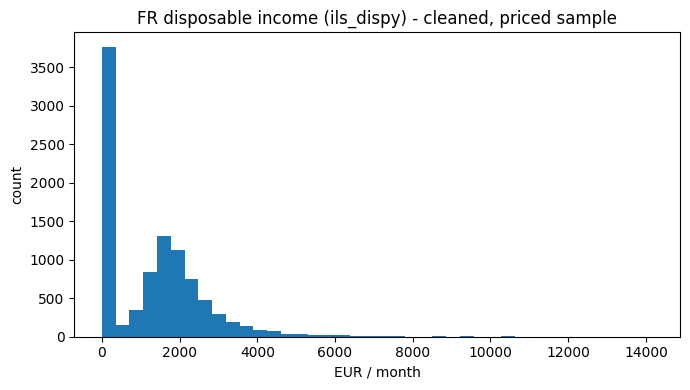

In [16]:
import matplotlib.pyplot as plt
c = pd.to_numeric(priced['ils_dispy'], errors='coerce')
print(c.describe())
plt.figure(figsize=(7, 4))
plt.hist(c.clip(lower=0), bins=40)
plt.title('FR disposable income (ils_dispy) - cleaned, priced sample')
plt.xlabel('EUR / month'); plt.ylabel('count'); plt.tight_layout(); plt.show()

---
## What you have after this
A clean line from your **original FR microdata** to a priced, inspectable sample, with the household funnel visible at every eligibility step. The only path I could not supply is your raw file (cell 0); the eligibility rules are your DE adapter's FR-mirror chain, the column names are EUROMOD-standard and checked in cell 1, and the FR-vs-DE differences (`is_worker`+lma, region kept, yem00/yemxp) are flagged where they bite.

**Next** (only if useful): build the latent-job alternatives from this cleaned sample (`generate_draws_long`) and price them — that step needs an FR earnings-mutation policy mirroring DE's `de_earnings_policy` (the yem00/yemxp 35h split), the one FR piece not yet written.

In [17]:
# ── 8. Restrict to singles (the trial scope) ──────────────────────────────
singles_df = df[df['household_class'] == 'single'].reset_index(drop=True)
print('singles households:', singles_df['idhh'].nunique(), '| persons:', len(singles_df))

# the modelled individuals = the single deciders (one per single household)
singles_dec = singles_df[singles_df['ruro_decider'] == 1].reset_index(drop=True)
print('single deciders   :', len(singles_dec),
      '| female share   :', round(singles_dec['female'].mean(), 3))

singles_dec[['idhh','dag','dgn','female','les','lhw','is_worker',
             'wage_ruro','educL','educM','educH']].head(10)

singles households: 1555 | persons: 2236
single deciders   : 1555 | female share   : 0.541


,idhh,dag,dgn,female,les,lhw,is_worker,wage_ruro,educL,educM,educH
0,1495800,51,0,1,3,35,1,11.164835,1,0,0
1,1496401,40,0,1,3,45,1,14.636753,0,0,1
2,1502500,47,0,1,3,50,1,2.238462,1,0,0
3,1504300,38,1,0,3,55,1,25.919580,0,0,1
4,1516900,37,0,1,3,35,1,23.769231,0,0,1
5,1526601,27,1,0,3,40,1,18.365384,0,0,1
6,1527000,28,1,0,3,35,1,12.000000,0,0,1
7,1533500,31,1,0,3,45,1,8.970085,0,1,0
8,1535100,43,0,1,3,35,1,22.626374,0,0,1
9,1537301,29,1,0,3,20,1,9.346154,0,0,1


In [18]:
# ── 9. Discover the REAL draws / engine-ready API (no guessing) ────────────
import importlib, inspect, pkgutil
import dclaborsupply, dclaborsupply_app

def show_api(pkg):
    for m in pkgutil.walk_packages(pkg.__path__, pkg.__name__ + '.'):
        if any(k in m.name.lower() for k in
               ['draw', 'alternativ', 'continuous', 'engine_ready', 'prep', 'pricing']):
            try:
                mod = importlib.import_module(m.name)
            except Exception as e:
                print(f'MODULE {m.name}  (import failed: {e})'); continue
            members = [(n, o) for n, o in vars(mod).items()
                       if (inspect.isfunction(o) or inspect.isclass(o))
                       and not n.startswith('_')
                       and getattr(o, '__module__', '') == m.name]
            if members:
                print(f'\nMODULE {m.name}')
                for n, o in members:
                    try: sig = str(inspect.signature(o))
                    except (ValueError, TypeError): sig = '(...)'
                    doc = (inspect.getdoc(o) or '').split('\n')[0]
                    print(f'   {n}{sig}')
                    if doc: print(f'        └ {doc[:90]}')

print('================ dclaborsupply (core) ================')
show_api(dclaborsupply)
print('\n================ dclaborsupply_app (DE template + euromod) ================')
show_api(dclaborsupply_app)

================ dclaborsupply (core) ================

MODULE dclaborsupply.alternatives.continuous
   generate_draws_long(df: 'pd.DataFrame', *, n_draws: 'int' = 99, wage_spec: 'str' = 'vw', occ_spec: 'str' = 'fixed', occ_strata: 'tuple[str, ...]' = ('dgn', 'educ3'), occ_min_cell: 'int' = 30, pi0_m: 'float' = 0.1, pi0_f: 'float' = 0.1, h_min: 'float' = 5.0, h_max: 'float' = 70.0, w_min: 'float' = 2.0, w_max: 'float' = 170.0, rng_seed: 'int' = 17) -> 'pd.DataFrame'
        └ Take a RURO_ready dataset (one row per person) and return a long dataset
   build_continuous_alternatives(df: 'pd.DataFrame', **kwargs) -> 'pd.DataFrame'
        └ Thin alias for :func:`generate_draws_long` (skeleton API compatibility).

MODULE dclaborsupply.alternatives.job_grid
   build_job_grid(*args: 'Any', **kwargs: 'Any') -> 'Any'
        └ Build job-choice alternatives once that trajectory is migrated.

================ dclaborsupply_app (DE template + euromod) ================

MODULE dclaborsupply_app.de.

In [19]:
# ── 10 (revised). Full columns + probe generate_draws_long ─────────────────
import numpy as np, traceback
from dclaborsupply.alternatives.continuous import generate_draws_long

if 'educ3' not in singles_dec.columns:
    singles_dec['educ3'] = np.select(
        [singles_dec['educL'] == 1, singles_dec['educM'] == 1, singles_dec['educH'] == 1],
        [0, 1, 2], default=-1).astype(int)

# (1) everything singles_dec carries — so I map the right wage/occ/loc column names
print('--- singles_dec columns ---')
print(sorted(singles_dec.columns)); print()

# (2) probe the real function on 5 rows; surface exactly what it wants
try:
    out = generate_draws_long(singles_dec.head(5).copy(), n_draws=4, rng_seed=17)
    print('PROBE OK — output shape:', out.shape)
    print('output columns:', list(out.columns))
    display(out.head(12))
except Exception as e:
    print('PROBE NEEDS:', type(e).__name__, '->', e)
    traceback.print_exc()

--- singles_dec columns ---
['aca', 'aco', 'afc', 'age_norm', 'age_norm2', 'amrrm', 'amrtn', 'ate', 'bch00', 'bchcc', 'bched', 'bchlg', 'bchot', 'bchyc', 'bdi', 'bed', 'bfa', 'bhl', 'bho', 'bhoot', 'bhotn', 'bsa', 'bsa00', 'bsaoa', 'bsaot', 'bsuwd', 'bun', 'bunct', 'bunmt', 'bunmy', 'dag', 'dct', 'dcu', 'dcz', 'ddi', 'ddt', 'dec', 'decde', 'deh', 'dehde', 'dew', 'dey', 'dgn', 'dmb', 'dms', 'dncsy', 'drg01', 'drgmd', 'drgn1', 'drgn2', 'drgru', 'drgur', 'dsu00', 'dsu01', 'dsu02', 'dwt', 'e20ps_o', 'e20pslw_o', 'e20psmd_o', 'e20pspo_o', 'educ3', 'educH', 'educL', 'educM', 'female', 'household_class', 'idfather', 'idhh', 'idmother', 'idorighh', 'idorigperson', 'idpartner', 'idperson', 'is_worker', 'kfb', 'kfbcc', 'kfbmy', 'kivho', 'lcs', 'les', 'lfs', 'lhw', 'lhw_f', 'lindi', 'liwftmy', 'liwmy', 'liwmy_f', 'liwptmy', 'liwwh', 'liwwh_f', 'loc', 'lowas', 'lpemy', 'lse', 'lunmy', 'lunmy_f', 'pdi', 'pdi00', 'pdimy', 'poa', 'poa00', 'poamy', 'psu', 'psumy', 'ruro_decider', 'tad', 'tis', 'tscer'

,idhh,idperson,idfather,idmother,idpartner,idorighh,idorigperson,dag,dmb,dgn,dms,dcz,ddi,drgur,drgmd,drgru,ddt,dwt,dsu00,dsu01,dsu02,dncsy,dcu,dct,dec,decde,deh,dehde,dey,dew,drgn2,drgn1,drg01,les,lcs,lfs,lindi,liwmy,liwftmy,liwptmy,...,e20pspo_o,e20psmd_o,e20pslw_o,liwmy_f,lhw_f,liwwh_f,lunmy_f,yem_f,yse_f,household_class,ruro_decider,is_worker,working,working_pt1,working_pt2,working_ft,working_lh,educL,educM,educH,wage_for_draws,wage_ruro,age_norm,age_norm2,female,educ3,idperson_true,idhh_true,hours,lhw_base,yivwg_base,wage,draw,is_decider,is_chosen,log_q_state,log_q_hours,log_q_wage,log_q_occ,log_q_total
0,1495800,149580001,0,0,0,1495800,149580001,51,11,0,1,3,0,1,0,0,22016,4997.319,0,147,428,0,0,5,0,-1,1,100,5,1979,1,1,1,3,0,5,8,12,12,0,...,0,1,0,1,1,1,1,1,1,single,1,1,1,0,0,0,0,1,0,0,11.164835,11.164835,9.896478,97.940283,1,0,149580001,1495800,35.000000,35,11.164835,11.164835,0,1,1,-0.105361,-4.174387,-5.123964,0.0,-9.403712
1,1495800,149580001,0,0,0,1495800,149580001,51,11,0,1,3,0,1,0,0,22016,4997.319,0,147,428,0,0,5,0,-1,1,100,5,1979,1,1,1,3,0,5,8,12,12,0,...,0,1,0,1,1,1,1,1,1,single,1,1,1,0,0,0,0,1,0,0,11.164835,88.454072,9.896478,97.940283,1,0,149580001,1495800,15.719944,35,11.164835,88.454072,1,1,0,-0.105361,-4.174387,-5.123964,0.0,-9.403712
2,1495800,149580001,0,0,0,1495800,149580001,51,11,0,1,3,0,1,0,0,22016,4997.319,0,147,428,0,0,5,0,-1,1,100,5,1979,1,1,1,3,0,5,8,12,12,0,...,0,1,0,1,1,1,1,1,1,single,1,1,1,0,0,0,0,1,0,0,11.164835,48.887619,9.896478,97.940283,1,0,149580001,1495800,35.027264,35,11.164835,48.887619,2,1,0,-0.105361,-4.174387,-5.123964,0.0,-9.403712
3,1495800,149580001,0,0,0,1495800,149580001,51,11,0,1,3,0,1,0,0,22016,4997.319,0,147,428,0,0,5,0,-1,1,100,5,1979,1,1,1,3,0,5,8,12,12,0,...,0,1,0,1,1,1,1,1,1,single,1,1,1,0,0,0,0,1,0,0,11.164835,107.826257,9.896478,97.940283,1,0,149580001,1495800,41.855235,35,11.164835,107.826257,3,1,0,-0.105361,-4.174387,-5.123964,0.0,-9.403712
4,1495800,149580001,0,0,0,1495800,149580001,51,11,0,1,3,0,1,0,0,22016,4997.319,0,147,428,0,0,5,0,-1,1,100,5,1979,1,1,1,3,0,5,8,12,12,0,...,0,1,0,1,1,1,1,1,1,single,1,1,1,0,0,0,0,1,0,0,11.164835,82.504058,9.896478,97.940283,1,0,149580001,1495800,34.374100,35,11.164835,82.504058,4,1,0,-0.105361,-4.174387,-5.123964,0.0,-9.403712
5,1496401,149640101,0,0,0,1496401,149640002,40,11,0,1,1,0,1,0,0,22016,11732.740,0,147,119,0,0,5,0,-1,5,500,18,2004,1,1,1,3,1,50,6,12,12,0,...,0,0,0,1,1,1,1,1,1,single,1,1,1,0,0,0,1,0,0,1,14.636753,14.636753,-1.103522,1.217760,1,2,149640101,1496401,45.000000,45,14.636753,14.636753,0,1,1,-0.105361,-4.174387,-5.123964,0.0,-9.403712
6,1496401,149640101,0,0,0,1496401,149640002,40,11,0,1,1,0,1,0,0,22016,11732.740,0,147,119,0,0,5,0,-1,5,500,18,2004,1,1,1,3,1,50,6,12,12,0,...,0,0,0,1,1,1,1,1,1,single,1,1,1,0,0,0,1,0,0,1,14.636753,111.752521,-1.103522,1.217760,1,2,149640101,1496401,64.785419,45,14.636753,111.752521,1,1,0,-0.105361,-4.174387,-5.123964,0.0,-9.403712
7,1496401,149640101,0,0,0,1496401,149640002,40,11,0,1,1,0,1,0,0,22016,11732.740,0,147,119,0,0,5,0,-1,5,500,18,2004,1,1,1,3,1,50,6,12,12,0,...,0,0,0,1,1,1,1,1,1,single,1,1,1,0,0,0,1,0,0,1,14.636753,93.096367,-1.103522,1.217760,1,2,149640101,1496401,57.970073,45,14.636753,93.096367,2,1,0,-0.105361,-4.174387,-5.123964,0.0,-9.403712
8,1496401,149640101,0,0,0,1496401,149640002,40,11,0,1,1,0,1,0,0,22016,11732.740,0,147,119,0,0,5,0,-1,5,500,18,2004,1,1,1,3,1,50,6,12,12,0,...,0,0,0,1,1,1,1,1,1,single,1,1,1,0,0,0,1,0,0,1,14.636753,22.363472,-1.103522,1.217760,1,2,149640101,1496401,31.075794,45,14.636753,22.363472,3,1,0,-0.105361,-4.174387,-5.123964,0.0,-9.403712
9,1496401,149640101,0,0,0,1496401,149640002,40,11,0,1,1,0,1,0,0,22016,11732.740,0,147,119,0,0,5,0,-1,5,500,18,2004,1,1,1,3,1,50,6,12,12,0,...,0,0,0,1,1,1,1,1,1,single,1,1,1,0,0,0,1,0,0,1,14.636753,154.667988,-1.103522,1.217760,1,2,149640101,1496401,18.205501,45,14.636753,154.667988,4,1,0,-0.105361,-4.174387,-5.123964,0.0,-9.403712


In [ ]:
# ── 11. Generate the singles draws (99 sampled + draw 0 observed = 100) ────
m = singles_dec['female'] == 0; f = singles_dec['female'] == 1
pi0_m = float((singles_dec.loc[m, 'is_worker'] == 0).mean())
pi0_f = float((singles_dec.loc[f, 'is_worker'] == 0).mean())
print(f'observed non-employment  men: {pi0_m:.3f}  women: {pi0_f:.3f}')

draws_long = generate_draws_long(
    singles_dec,
    n_draws=99,                 # 99 sampled + draw 0 (observed) = 100 alternatives
    wage_spec='vw',             # CONFIRM == spec.wage_spec
    occ_spec='fixed',           # CONFIRM vs spec's occupation treatment (see note below)
    occ_strata=('dgn', 'educ3'),
    pi0_m=pi0_m, pi0_f=pi0_f,
    h_min=5.0,  h_max=70.0,
    w_min=2.0,  w_max=170.0,
    rng_seed=17,
)
print('draws_long shape:', draws_long.shape, '  (expect 155500)')

In [ ]:
# ── 12. Canonicalize the post-draw non-employment state + inspect ──────────
from dclaborsupply_app.de.draws_prep import (canonicalize_post_draws,
                                             assert_choice_state_consistent)
draws_canon = canonicalize_post_draws(draws_long)
assert_choice_state_consistent(draws_canon)
print('canonicalized; consistent. rows:', len(draws_canon),
      '| persons:', draws_canon['idperson_true'].nunique())

kcol = 'idperson_true' if 'idperson_true' in draws_canon.columns else 'idperson'
one = draws_canon[draws_canon[kcol] == draws_canon[kcol].iloc[0]]
cols = [c for c in ['draw','is_chosen','hours','wage','is_worker',
                    'log_q_hours','log_q_wage','log_q_occ','log_q_total'] if c in one.columns]
one[cols].sort_values('draw').head(20)

In [ ]:
# ── 13. Read the DE earnings-policy body (basis for the FR version) ────────
import inspect
from dclaborsupply_app.de.pricing import de_earnings_policy
print(inspect.getsource(de_earnings_policy))